# Build SDS archive and segment out event waveform files

## 1. Global parameters and imports


In [2]:
from pathlib import Path
from obspy import read, UTCDateTime, Stream
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from flovopy.seisanio.utils.helpers import write_wavfile

TOP_PATH = Path('/Volumes') / 'tachyon' / 'Artemis2'
#TOP_PATH = Path('/Volumes') / 'Pulwtop' / 'Artemis2'
SDS_DATA_PATH = TOP_PATH / '20_archive' / 'SDS'
WAV_PATH = TOP_PATH / '30_eventwav'

client = EnhancedSDSClient(str(SDS_DATA_PATH))  
launchtime = UTCDateTime('2026-04-01T22:35:12')
duration = 900
pretrigger = 1800
posttrigger = pretrigger
starttime=launchtime - pretrigger
endtime=launchtime + duration + posttrigger

def eventwav_path(launchtime, wav_path=WAV_PATH):
    return wav_path / f'{launchtime.year:04d}' / f'{launchtime.month:02d}'

## 2. USF Nanometrics stations
Already in an SDS archive, so just need to write out event file

In [ ]:
st = client.get_waveforms(network='1R', station='*', location='*', channel='D*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'USF', len(st))

# 3. Guralp stations
Files downloaded through web interface

In [ ]:
GURALP_PATH = TOP_PATH / '00_download' / 'Guralp'

for station in ['B07', 'B12']:
    MSEED_PATH = GURALP_PATH / station
    station_files = sorted(list(MSEED_PATH.glob('*.mseed')))
    for station_file in station_files:
        print(f'Processing {station_file}...')
        st_station = read(str(station_file))
        client.write_stream(st_station)

Files downloaded with wget - it creates an sd/ folder

In [ ]:
MSEED_PATH = GURALP_PATH / 'B12' / 'sd'
station_files = sorted(list(MSEED_PATH.glob('*S1Seis*.mseed')))
for station_file in station_files:
    print(f'Processing {station_file}...')
    st_station = read(str(station_file))
    client.write_stream(st_station)

In [ ]:
st = client.get_waveforms(network='DG', station='*', location='*', channel='C*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'MSFC', len(st))

# 4. BSU Gem sensors
Already copied all files from microSD cards to a single raw/ directory, and then ran gemconvert.
This created an mseed folder
Now we need to loop over the files in that folder, and write them to an SDS archive.

In [5]:
GEM_MSEED_PATH = TOP_PATH / '10_gemconvert' / 'mseed'
GEM_MSEED_PATH = TOP_PATH / '00_download' / 'gem' / 'mseed'
def fix_gem_trace_id(tr):
    id_dict = {
        '273': '1R.B24LT..HDF',
        '287': '1R.B24RE..HDF',
        '288': '1R.B24..HDF',
        '275': '1R.B24..HDI',
        '296': '1R.B29..HDF',
        '292': '1R.B29..HDI',
        '369': '1R.B12..HDF',
        '290': '1R.B23..HDF',
        '256': '1R.B03..HDF',
        '254': '1R.B03..HDI',
        '246': '1R.B14..HDF',
        '244': '1R.B14..HDI',
        '362': '1R.B01..HDF',
        '251': '1R.B01..HDI',
        '274': '1R.B07.10.HDF',
        '365': '1R.B07..HDF',
        '285': '1R.B20..HDF',
        '361': '1R.B20..HDI',
        '294': '1R.B20.10.HDI',
        '364': '1R.B20W..HDF',
        '366': '1R.B20S..HDF',
        '363': '1R.UNK..HD1' # what is 363, where was it?
    }
    tr.id = id_dict.get(tr.stats.station, tr.id)

for file in sorted(GEM_MSEED_PATH.glob('*.mseed')):
    st = read(str(file))
    for tr in st:
        fix_gem_trace_id(tr)
    print(st)
    print(f"Writing stream for file: {file}")
    client.write_stream(st)    

1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-10T17:45:14.000000Z - 2026-03-10T23:59:59.990000Z | 100.0 Hz, 2248600 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-10T17_45_14..275..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-11T00:00:00.000000Z - 2026-03-11T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-11T00_00_00..275..HDF.mseed
1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-11T14:50:43.000000Z - 2026-03-11T23:59:59.990000Z | 100.0 Hz, 3295700 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-11T14_50_43..363..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-12T00:00:00.000000Z - 2026-03-12T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-12T00_00_00..275..HDF.mseed


/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-12T00:00:00.000000Z - 2026-03-12T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-12T00_00_00..363..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-13T00:00:00.000000Z - 2026-03-13T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-13T00_00_00..275..HDF.mseed
1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-13T00:00:00.000000Z - 2026-03-13T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-13T00_00_00..363..HDF.mseed
1 Trace(s) in Stream:
1R.B24..HDI | 2026-03-14T00:00:00.000000Z - 2026-03-14T23:59:59.990000Z | 100.0 Hz, 8640000 samples
Writing stream for file: /Volumes/Pulwtop/Artemis2/00_download/gem/mseed/2026-03-14T00_00_00..275..HDF.mseed
1 Trace(s) in Stream:
1R.UNK..HD1 | 2026-03-14T00:00:00.000000Z - 2026-03-14

Now let's read the Gem data from the SDS archive - it is the only HD* channel data in there 

In [ ]:
st = client.get_waveforms(network='1R', station='*', location='*', channel='HD*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'BSU', len(st))

# 5. Silicon Audio 1-minute files to SDS

In [ ]:
from siliconaudio import merge_miniseed_to_sds
from pathlib import Path

B23_PATH = TOP_PATH / '10_downloads'  / 'SiliconAudio' / 'B23' / 'data'
SDS_B23 = Path('/Volumes') / 'tachyon' / '20260403_DOWNLOAD' / 'B23' / 'dayfiles'

written = merge_miniseed_to_sds(
    input_root=B23_PATH,
    sds_root=SDS_DATA_PATH,
    pattern="*.ms",
    write_mode="merge",
    preprocess=False,
    verbose=True,
)


We want to compute 1-s VSAM (and ISAM or PSAM) and then use the peak RMS, and convert it to SPL
Then plot SPL versus distance

We also want to plot spectrograms

# 6. SmartSolo miniseed files to SDS
DLD files are copied off the SmartSolo internal cards using the SoloLite software.
Then these are converted to 1 miniseed file per channel per day.
Format is serial number, day number, YYYY, MM, DD, HH, MM, SS, 000, N/E/Z, miniseed, all separated by '.'
We need a translation table.



In [10]:
#SMARTSOLO_MSEED_PATH = TOP_PATH / '10_gemconvert' / 'mseed'
SMARTSOLO_MSEED_PATH = TOP_PATH.parent / 'SOLODATA' / 'prospect_ksc' / 'artemis2' / 'ten_stations'

def fix_smartsolo_trace_id(tr):
    chan = tr.stats.channel
    id_dict = {
        '453013783': '1R.B14..DH',
        '453013396': '1R.B01..DH',
        '453014357': '1R.B03..DH',
        '453014233': '1R.B12..DH',
        '453013322': '1R.B07..DH',
        '453012536': '1R.B24..DH',
        '453012683': '1R.B23..DH',  
        '453005764': '1R.B29..DH',
        '453013851': '1R.B20W..DH',
        '453019414': '1R.B20..DH',
        '453020406': '1R.B20S..DH',           
    }
    tr.id = id_dict.get('4530' + tr.stats.station, tr.id)
    tr.stats.channel = chan

files_not_read = []
files_not_fixed = []
files_not_written = []
for file in sorted(SMARTSOLO_MSEED_PATH.glob('*.miniseed')):
    print(file.name)
    try:
        st = read(str(file), header_only=True)
    except:
        files_not_read.append(file.name)
    for tr in st:
        fix_smartsolo_trace_id(tr)
        if tr.stats.network != '1R':
            files_not_fixed.append(file.name)
    print(st)
    print(f"Writing stream for file: {file}")
    try:
        client.write_stream(st)    
    except:
        files_not_written.append(file.name)

print(f'Files not read {files_not_read}')
print(f'Files not fixed {files_not_fixed}')
print(f'Files not written {files_not_written}')


453012536.0001.2026.03.10.17.51.54.000.E.miniseed
1 Trace(s) in Stream:
1R.B24..DPE | 2026-03-10T17:51:54.000000Z - 2026-03-11T00:00:00.000000Z | 500.0 Hz, 11043001 samples
Writing stream for file: /Volumes/tachyon/SOLODATA/prospect_ksc/artemis2/ten_stations/453012536.0001.2026.03.10.17.51.54.000.E.miniseed
453012536.0001.2026.03.10.17.51.54.000.N.miniseed
1 Trace(s) in Stream:
1R.B24..DPN | 2026-03-10T17:51:54.000000Z - 2026-03-11T00:00:00.000000Z | 500.0 Hz, 11043001 samples
Writing stream for file: /Volumes/tachyon/SOLODATA/prospect_ksc/artemis2/ten_stations/453012536.0001.2026.03.10.17.51.54.000.N.miniseed
453012536.0001.2026.03.10.17.51.54.000.Z.miniseed
1 Trace(s) in Stream:
1R.B24..DPZ | 2026-03-10T17:51:54.000000Z - 2026-03-11T00:00:00.000000Z | 500.0 Hz, 11043001 samples
Writing stream for file: /Volumes/tachyon/SOLODATA/prospect_ksc/artemis2/ten_stations/453012536.0001.2026.03.10.17.51.54.000.Z.miniseed
453012536.0002.2026.03.11.00.00.00.000.E.miniseed
1 Trace(s) in Stream:
1

In [11]:
st = client.get_waveforms(network='1R', station='*', location='*', channel='DP*', starttime=starttime, endtime=endtime)
write_wavfile(st, WAV_PATH, 'SmartSolo', len(st))

'/Volumes/tachyon/Artemis2/30_eventwav/2026/04/2026-04-01-2205-12M.SmartSolo_030'

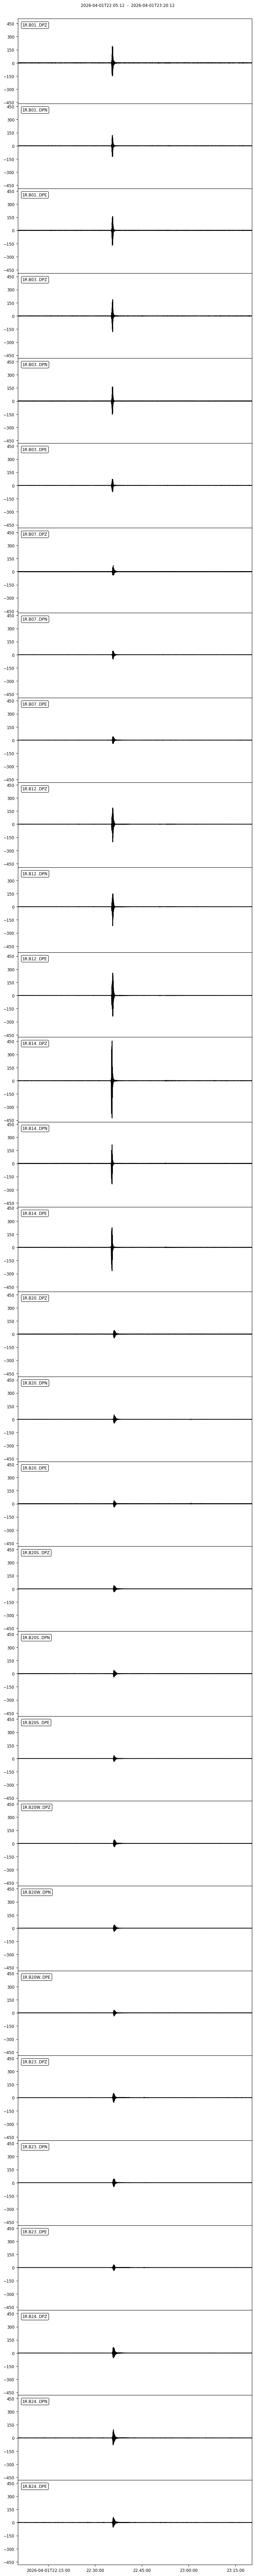

In [14]:
st.plot(equal_scale=True);

In [15]:
from obspy import read_inventory
inv = read_inventory('/Volumes/tachyon/FDSN*xml')

In [16]:
print(inv)

Inventory created at 2026-04-29T10:35:20.000000Z
	Created by: SOLOLITE
		    www.smartsolo.com www.dtcc.biz
	Sending institution: DTCC (DTCC)
	Contains:
		Networks (1):
			SS
		Stations (1):
			SS.13851 (13851)
		Channels (1):
			SS.13851.SW.DPZ


/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/obspy/core/inventory/response.py:1230: UserWarning: The unit 'MV' is not known to ObsPy. It will be passed in to evalresp as 'undefined'. This should result in evalresp using the response as is, without adding any integration or differentiation and the 'output' parameter (here: 'VEL') not having any effect. Please double check output data.
  warnings.warn(msg)
/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/obspy/core/inventory/response.py:2318: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="lower center", ncol=3, fontsize='small')


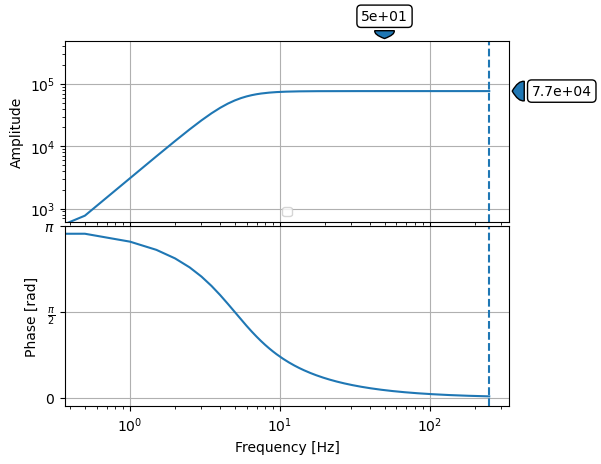

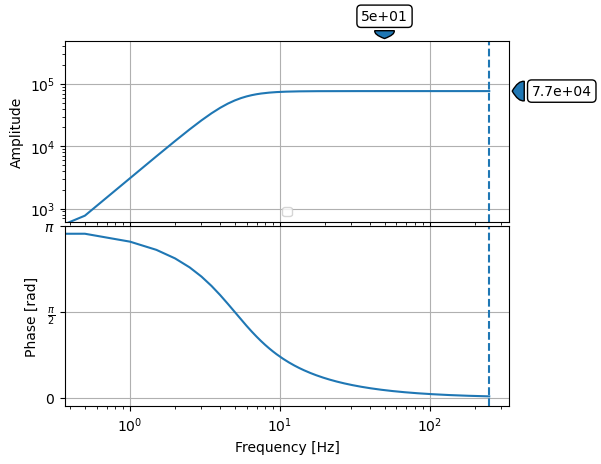

In [ ]:
smartsoloresp = inv[0].stations[0].channels[0].response


In [28]:
from copy import deepcopy
from pathlib import Path

import pandas as pd
from obspy import UTCDateTime, read_inventory
from obspy.core.inventory import Inventory, Network, Station, Channel, Site, Equipment

csv_file = Path("~/Downloads/for_chatgpt.csv")
template_xml = Path("/Volumes/tachyon/FDSN_Information_453013851_1.xml")
out_xml = Path("/Volumes/tachyon/KSC_SmartSolo_verticals.xml")

# Read the SmartSolo template response
template_inv = read_inventory(template_xml)
template_chan = template_inv[0][0][0]
smartsolo_response = template_chan.response

# Use timing / sample-rate defaults from the template XML
start_date = template_chan.start_date
end_date = template_chan.end_date
start_date = UTCDateTime(2026,3,10)
end_date=UTCDateTime(2026,4,5)
sample_rate = template_chan.sample_rate
location_code = template_chan.location_code or "SW"
location_code = ''
channel_code = template_chan.code  # DPZ

# Read station table
df = pd.read_csv(csv_file, encoding="utf-8-sig")

# Keep only rows with SmartSolo serial numbers
df = df.dropna(subset=["SmartSolo serial number"]).copy()
df["serial"] = df["SmartSolo serial number"].astype(int).astype(str)

net = Network(
    code="1R",
    description="KSC SmartSolo vertical geophone network",
    start_date=start_date,
)

for _, row in df.iterrows():
    station_code = str(row["Station"]).strip()
    serial = row["serial"]

    lat = float(row["Lat (o)"])
    lon = float(row["Lon (o)"])

    # If you have real elevations later, replace this.
    elev = 0.0

    sta = Station(
        code=station_code,
        latitude=lat,
        longitude=lon,
        elevation=elev,
        site=Site(name=f"{station_code} SmartSolo {serial}"),
        start_date=start_date,
        end_date=end_date,
    )

    chan = Channel(
        code=channel_code,
        location_code=location_code,
        latitude=lat,
        longitude=lon,
        elevation=elev,
        depth=0.0,
        azimuth=0.0,
        dip=90.0,          # vertical, positive down in StationXML convention
        sample_rate=sample_rate,
        start_date=start_date,
        end_date=end_date,
    )

    chan.sensor = Equipment(
        type="DTSOLO",
        description="SmartSolo digital geophone",
        manufacturer="DTCC",
        serial_number=serial,
    )

    chan.response = deepcopy(smartsolo_response)

    sta.channels.append(chan)
    net.stations.append(sta)

inv_out = Inventory(
    networks=[net],
    source="USF / generated from SmartSolo station table",
    sender="USF",
)

print(inv_out)
inv_out.write(out_xml, format="STATIONXML")
print(f"Wrote {out_xml}")

Inventory created at 2026-05-02T21:21:42.918136Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: USF / generated from SmartSolo station table (USF)
	Contains:
		Networks (1):
			1R
		Stations (11):
			1R.B01 (B01 SmartSolo 453013396)
			1R.B03 (B03 SmartSolo 453014357)
			1R.B07 (B07 SmartSolo 453013322)
			1R.B12 (B12 SmartSolo 453014233)
			1R.B14 (B14 SmartSolo 453013783)
			1R.B20 (B20 SmartSolo 453019414)
			1R.B20S (B20S SmartSolo 453020406)
			1R.B20W (B20W SmartSolo 453013851)
			1R.B23 (B23 SmartSolo 453012683)
			1R.B24 (B24 SmartSolo 453012536)
			1R.B29 (B29 SmartSolo 453005764)
		Channels (11):
			1R.B01..DPZ, 1R.B03..DPZ, 1R.B07..DPZ, 1R.B12..DPZ, 1R.B14..DPZ, 
			1R.B20..DPZ, 1R.B20S..DPZ, 1R.B20W..DPZ, 1R.B23..DPZ, 1R.B24..DPZ, 
			1R.B29..DPZ
Wrote /Volumes/tachyon/KSC_SmartSolo_verticals.xml


In [26]:
print(st)

30 Trace(s) in Stream:

1R.B01..DPE | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
...
(28 other traces)
...
1R.B24..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


In [31]:
st2 = st.copy()
for tr in st2.select(component='Z'):
    print(tr)
    tr.remove_response(inv_out)
#st2.remove_response(inv_out)

1R.B01..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/obspy/core/inventory/response.py:1230: UserWarning: The unit 'MV' is not known to ObsPy. It will be passed in to evalresp as 'undefined'. This should result in evalresp using the response as is, without adding any integration or differentiation and the 'output' parameter (here: 'VEL') not having any effect. Please double check output data.
  warnings.warn(msg)


1R.B03..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B07..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B12..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B14..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B20..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B20S..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B20W..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B23..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples
1R.B24..DPZ | 2026-04-01T22:05:12.000000Z - 2026-04-01T23:20:12.000000Z | 500.0 Hz, 2250001 samples


/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_plus/lib/python3.12/site-packages/obspy/imaging/waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


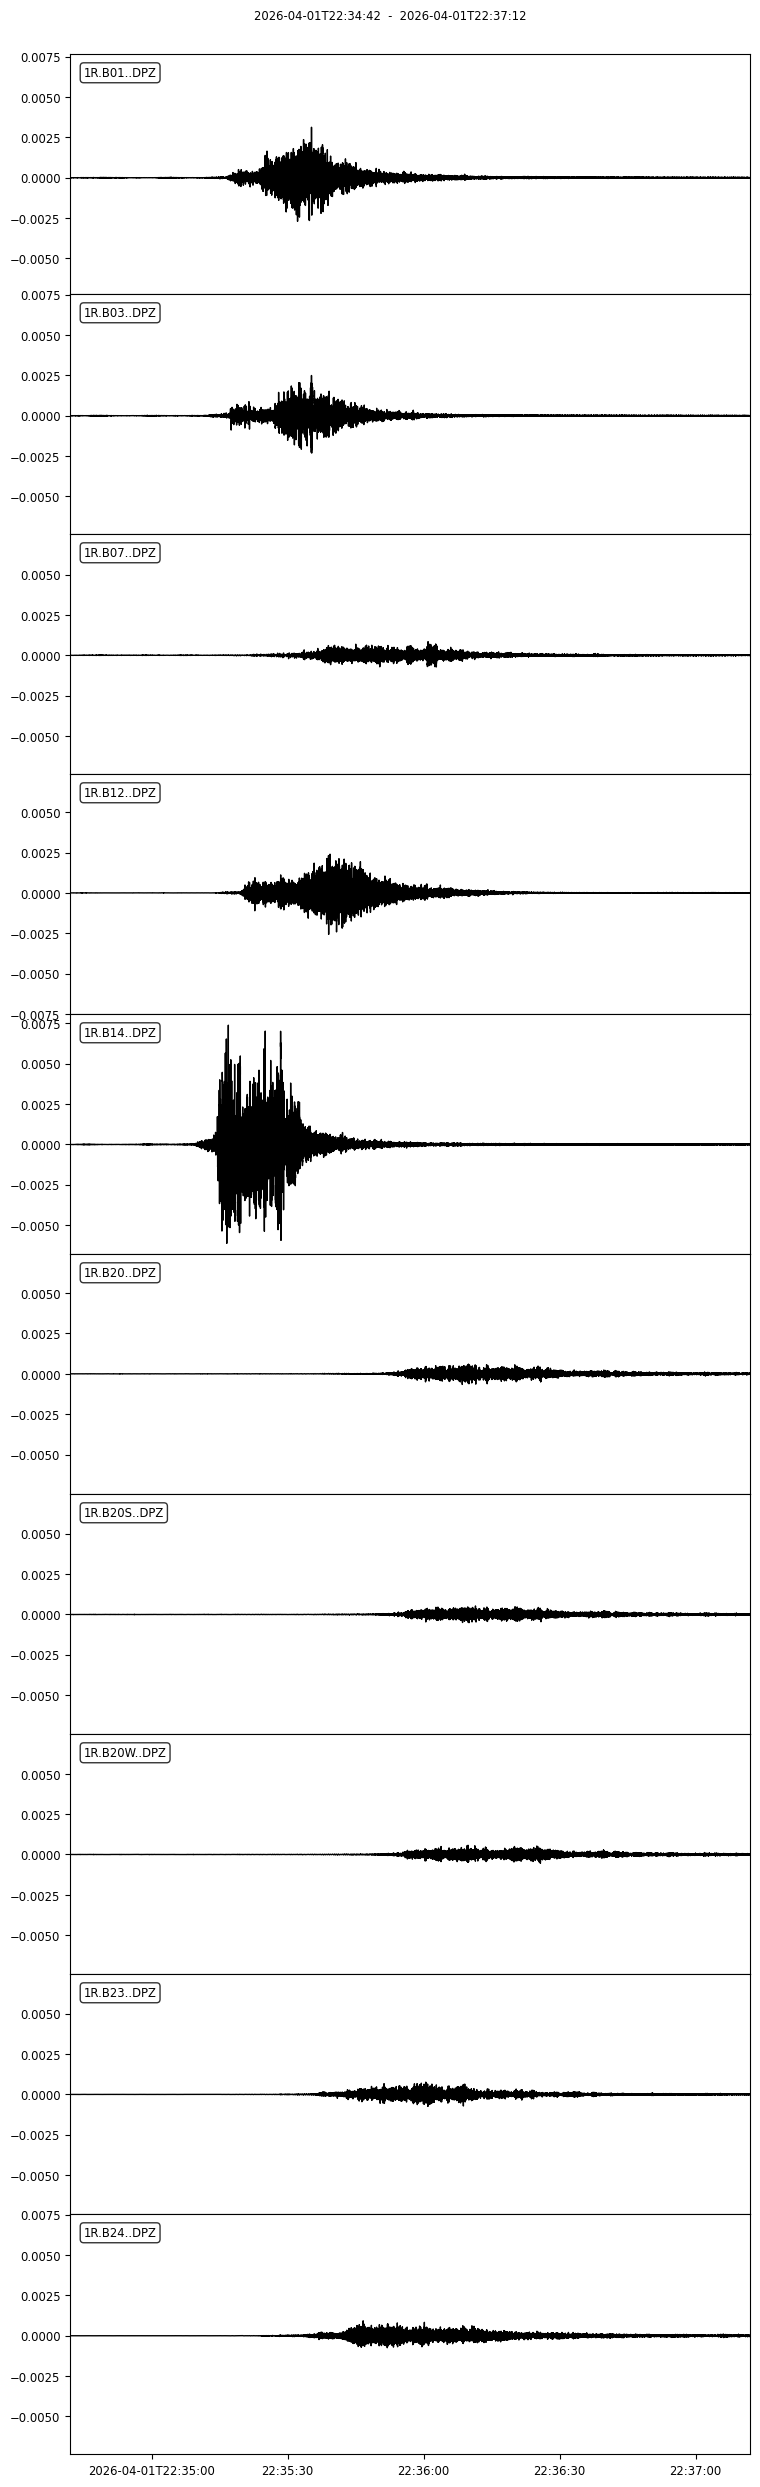

In [34]:
st2.select(component='Z').plot(starttime=launchtime-30, endtime=launchtime+120);